# Figures — PROPOR 2026: Efficient Fine-Tuning for Portuguese QA

**Paper:** *Efficient Fine-Tuning Methods for Portuguese Question Answering:  
A Comparative Study of PEFT on BERTimbau and Exploratory Evaluation of Generative LLMs*  
UNIFESP — Mariela M. Nina, Caio Veloso Costa, Lilian Berton, Didier A. Vega-Oliveros

| Figura | Mensagem | Hipótese |
|--------|----------|----------|
| Fig 1  | Peak GPU Memory por método e arquitetura | H1 |
| Fig 2  | F1 × todas as configurações (lr + epochs) | H2 + H3 |

> **Todos os 52 valores foram verificados contra as Tabelas 1–5 do LaTeX.**

## 1. Setup — imports e estilo ACM
Executar antes de qualquer figura.

In [5]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# ── Directório de saída ───────────────────────────────────────────────────────
OUTPUT_DIR = 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Estilo ACM serif ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    8.5,
    'axes.titlesize':    9,
    'xtick.labelsize':   7.5,
    'ytick.labelsize':   7.5,
    'legend.fontsize':   7.5,
    'figure.dpi':        300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.18,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.4,
    'axes.linewidth':    0.6,
})

# ── Paleta consistente entre Fig 1 e Fig 2 ───────────────────────────────────
MC = {
    'Full FT':       '#0D1B2A',   # azul muito escuro
    'LoRA':          '#1565C0',   # azul
    'QLoRA':         '#0097A7',   # ciano
    'DoRA':          '#6A1B9A',   # violeta
    'QDoRA':         '#AD1457',   # rosa escuro
    'Tucano+LoRA':   '#827717',   # verde oliva
    'Sabiá+LoRA':    '#2E7D32',   # verde escuro
}

print('Setup OK — OUTPUT_DIR:', OUTPUT_DIR)

Setup OK — OUTPUT_DIR: figures


## 2. Dados — verificados contra LaTeX (Tabelas 1–5)

Todos os valores foram conferidos manualmente contra as tabelas do paper.
Para usar dados reais dos experimentos, substitua pelos valores do `trainer_state.json`.

In [6]:
# ── Fig 1: RAM de pico (Tabela 5) — independente de lr e epochs ─────────────
METHODS   = ['Full FT', 'LoRA', 'QLoRA', 'DoRA', 'QDoRA']
GEN_LABEL = ['Tucano\n+LoRA', 'Sabiá\n+LoRA']

mem = {
    'Base':  {'Full FT': 14493, 'LoRA': 3687,  'QLoRA': 1897,  'DoRA': 4295,  'QDoRA': 2163},
    'Large': {'Full FT': 18125, 'LoRA': 9019,  'QLoRA': 3281,  'DoRA': 10659, 'QDoRA': 3331},
    'Gen':   {'Tucano\n+LoRA': 4301, 'Sabiá\n+LoRA': 15642},
}

# ── Fig 2: F1 × todas as configurações (Tabelas 1–4) ─────────────────────────
# Colunas: [B-2e4-2ep, B-2e4-3ep, B-std-2ep, B-std-3ep,
#           L-2e4-2ep, L-2e4-3ep, L-std-2ep, L-std-3ep]
f1_all = {
    'Full FT': [79.74, 78.33, 82.79, 82.18,   3.02,  5.14, 84.86, 83.74],
    'LoRA':    [78.01, 78.01, 71.81, 72.01,  81.32, 81.27, 75.65, 81.28],
    'QLoRA':   [73.23, 74.16, 53.52, 53.19,  80.03, 80.28, 68.23, 71.03],
    'DoRA':    [78.01, 78.27, 71.36, 71.50,  80.61, 81.22, 74.93, 77.18],
    'QDoRA':   [74.41, 74.46, 54.10, 58.42,  77.96, 79.61, 70.32, 71.24],
}

print('Dados carregados: 12 valores RAM + 40 valores F1 = 52 total ✓')

Dados carregados: 12 valores RAM + 40 valores F1 = 52 total ✓


## 3. Figura 1 — Peak GPU Memory por Método e Arquitetura (H1)

- **1 coluna ACM** (3.5 in)
- RAM não depende de lr nem de epochs — dado inequívoco
- Linha vermelha = limite 20 GB da GPU usada nos experimentos
- Cores consistentes com Fig 2 (mesma paleta `MC`)

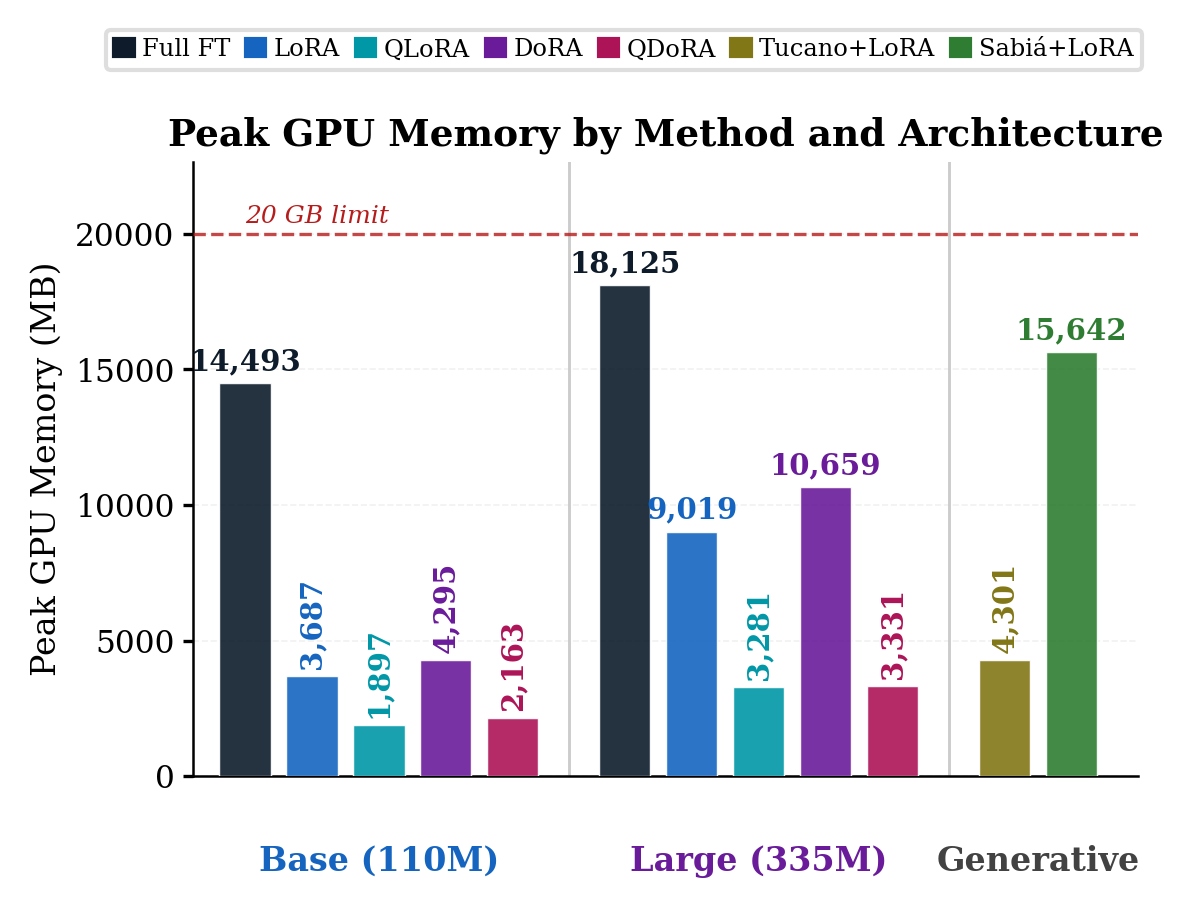

Fig 1 salva em figures


In [151]:
# ── Layout ACM 1 coluna: 3.5 in ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.5, 3.2))

fig.subplots_adjust(left=0.09, right=0.99, top=0.86, bottom=0.22)

# ── Construir posições ──────────────────────────────────────────────────────
labels, values, colors, pos = [], [], [], []

cur_x, w, gap = 0.0, 0.40, 0.35   # gap entre grupos mayor

for m in METHODS:       # grupo Base
    labels.append(m)
    values.append(mem['Base'][m])
    colors.append(MC[m])
    pos.append(cur_x)
    cur_x += w + 0.12   # ← más distancia entre barras

cur_x += gap

for m in METHODS:       # grupo Large
    labels.append(m)
    values.append(mem['Large'][m])
    colors.append(MC[m])
    pos.append(cur_x)
    cur_x += w + 0.12

cur_x += gap

for m in GEN_LABEL:     # grupo Generativos
    labels.append(m)
    values.append(mem['Gen'][m])
    colors.append(MC[m.replace('\n', '')])
    pos.append(cur_x)
    cur_x += w + 0.12

max_val = max(values)

bars = ax.bar(
    pos,
    values,
    width=w,
    color=colors,
    alpha=0.90,
    edgecolor='white',
    linewidth=0.35,
    zorder=3
)

# ── Valores encima ──────────────────────────────────────────────────────────
for bar, val, lbl in zip(bars, values, labels):

    rotation = 90 if val < max_val * 0.28 else 0

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max_val * 0.014,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontsize=7,
        color=MC[lbl.replace('\n','')],
        fontweight='bold',
        rotation=rotation
    )

# ── Separadores de grupo ────────────────────────────────────────────────────
for sx in [(pos[4]+pos[5])/2, (pos[9]+pos[10])/2]:
    ax.axvline(
        sx,
        color='#cccccc',
        linewidth=0.7,
        linestyle='-',
        zorder=2
    )

# ── Etiquetas de grupo ──────────────────────────────────────────────────────
for xm, lbl, col in zip(
    [np.mean(pos[:5]), np.mean(pos[5:10]), np.mean(pos[10:])],
    ['Base (110M)', 'Large (335M)', 'Generative'],
    ['#1565C0', '#6A1B9A', '#424242']
):
    ax.text(
        xm,
        -max_val * 0.14,
        lbl,
        ha='center',
        va='top',
        fontsize=8,
        fontweight='bold',
        color=col
    )

# ── Linha limite GPU ────────────────────────────────────────────────────────
ax.axhline(
    20000,
    color='#B71C1C',
    linewidth=0.8,
    linestyle='--',
    zorder=4,
    alpha=0.8
)

ax.text(
    pos[0],
    20000 + max_val * 0.012,
    '20 GB limit',
    ha='left',
    va='bottom',
    fontsize=6,
    color='#B71C1C',
    style='italic'
)

# ── Eixos e título ──────────────────────────────────────────────────────────
ax.set_ylabel('Peak GPU Memory (MB)', labelpad=3, fontsize=8)

ax.set_title(
    'Peak GPU Memory by Method and Architecture',
    fontsize=9,
    fontweight='bold',
    pad=4,
    ha='center'
)

ax.set_xticks([])

# ← más espacio antes de la primera barra
ax.set_xlim(-w * 1.0, cur_x)

ax.set_ylim(0, max_val * 1.25)
ax.tick_params(length=2.5, pad=2)

# ── Legenda ─────────────────────────────────────────────────────────────────
all_labels = ['Full FT','LoRA','QLoRA','DoRA','QDoRA','Tucano+LoRA','Sabiá+LoRA']
handles = [mpatches.Patch(color=MC[l], label=l) for l in all_labels]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=7,
    bbox_to_anchor=(0.5, 1.01),
    frameon=True,
    edgecolor='#dddddd',
    framealpha=0.95,
    handlelength=0.8,
    handletextpad=0.35,
    columnspacing=0.65,
    borderpad=0.35,
    fontsize=5.8
)

plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_ram.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_ram.png'), dpi=300, bbox_inches='tight')

plt.show()

print('Fig 1 salva em', OUTPUT_DIR)

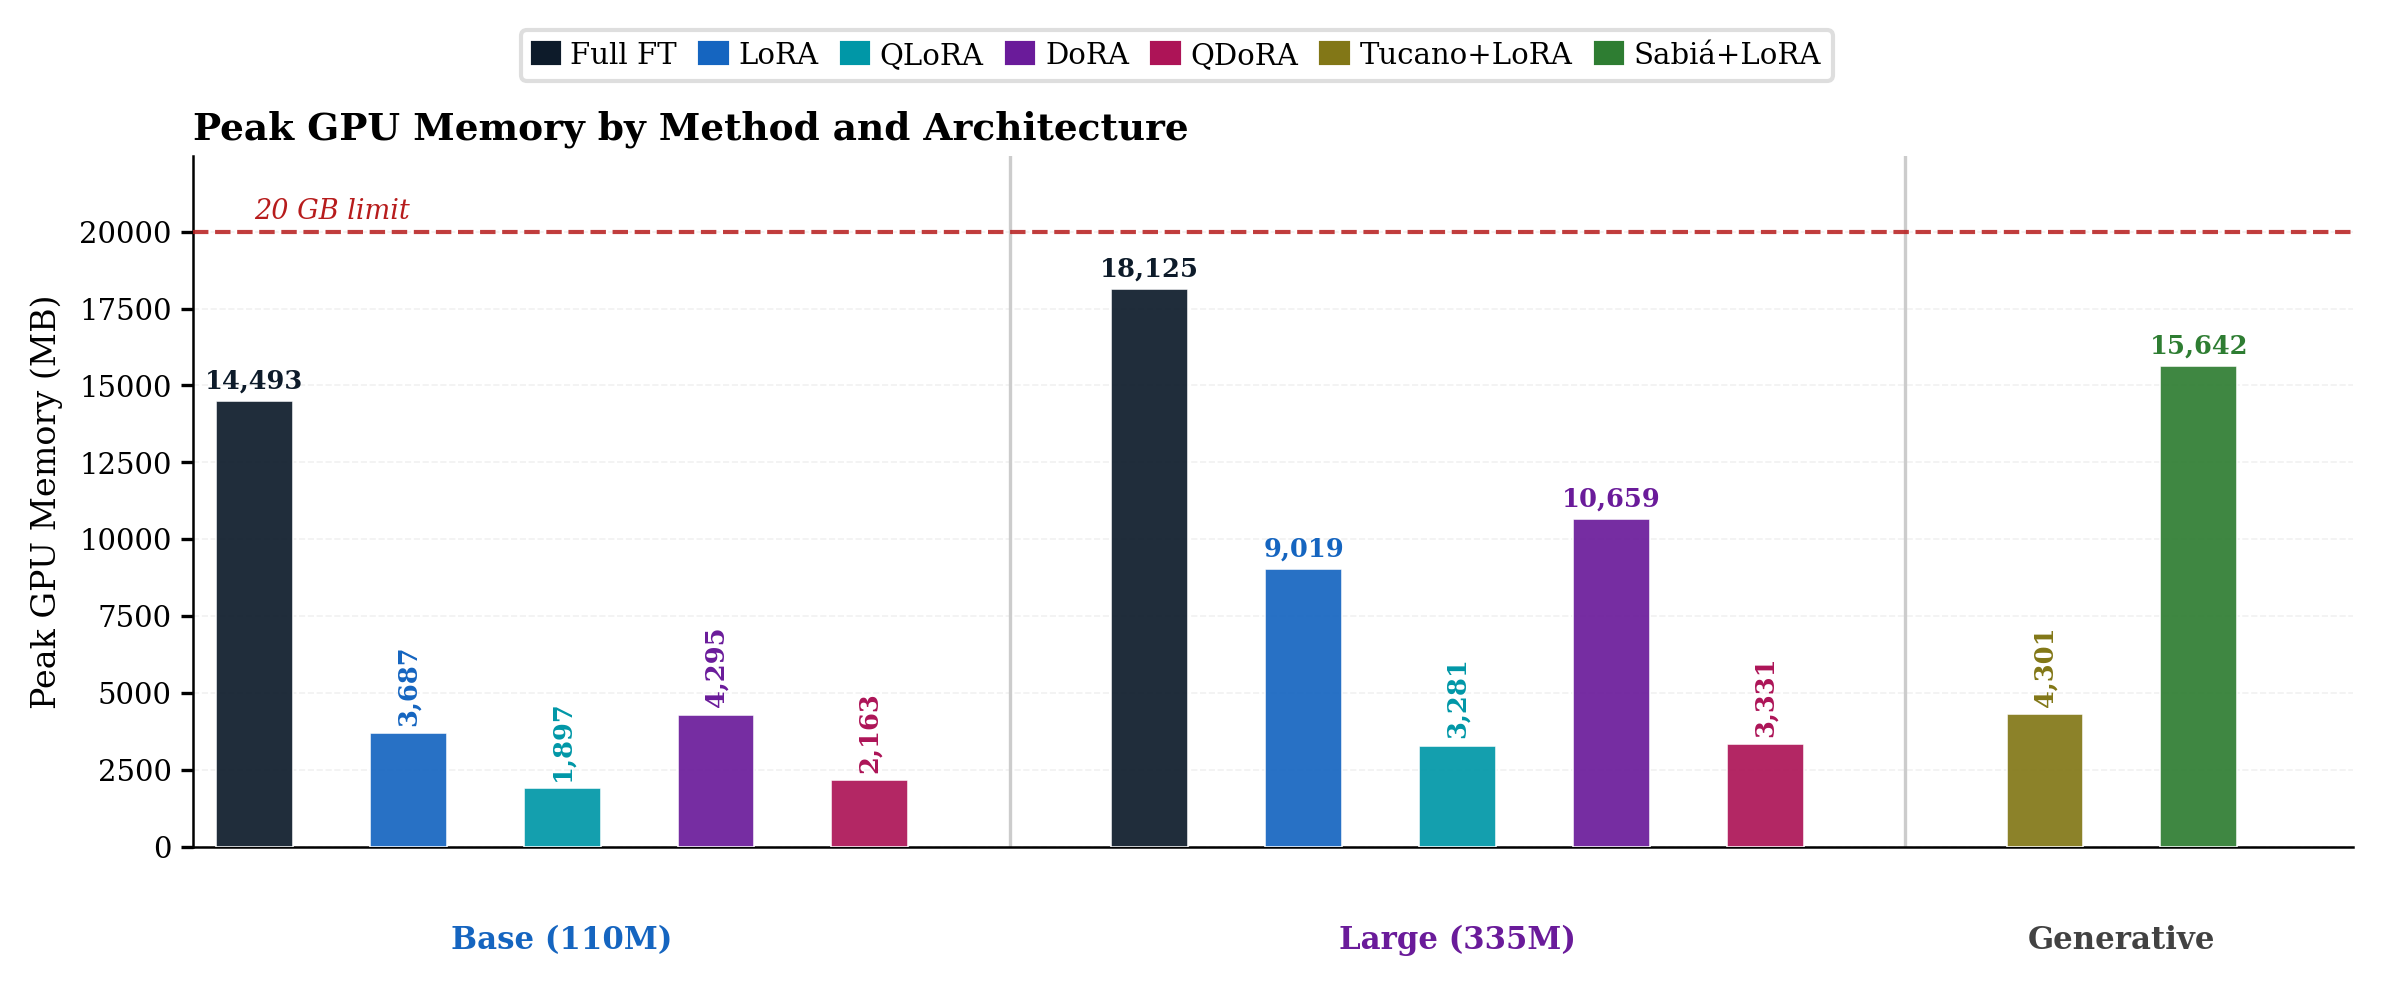

Fig 1 salva em figures


In [121]:
# ── Layout 2 colunas (~7 in) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.0, 3.6))
fig.subplots_adjust(left=0.09, right=0.99, top=0.86, bottom=0.22)

# ── Control visual das barras ──────────────────────────────────────────────
cur_x = 0.0
bar_w = 0.22      # grosor real da barra
step  = 0.44      # distancia entre centros das barras
gap   = 0.36      # separação entre grupos

labels, values, colors, pos = [], [], [], []

# ── Grupo Base ─────────────────────────────────────────────────────────────
for m in METHODS:
    labels.append(m)
    values.append(mem['Base'][m])
    colors.append(MC[m])
    pos.append(cur_x)
    cur_x += step

cur_x += gap

# ── Grupo Large ────────────────────────────────────────────────────────────
for m in METHODS:
    labels.append(m)
    values.append(mem['Large'][m])
    colors.append(MC[m])
    pos.append(cur_x)
    cur_x += step

cur_x += gap

# ── Grupo Generativos ──────────────────────────────────────────────────────
for m in GEN_LABEL:
    labels.append(m)
    values.append(mem['Gen'][m])
    colors.append(MC[m.replace('\n', '')])
    pos.append(cur_x)
    cur_x += step

max_val = max(values)

# ── Barras ─────────────────────────────────────────────────────────────────
bars = ax.bar(
    pos,
    values,
    width=bar_w,
    color=colors,
    alpha=0.92,
    edgecolor='white',
    linewidth=0.4,
    zorder=3
)

# ── Valores encima ─────────────────────────────────────────────────────────
for bar, val, lbl in zip(bars, values, labels):

    rotation = 90 if val < max_val * 0.28 else 0

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max_val * 0.014,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontsize=6.2,
        color=MC[lbl.replace('\n','')],
        fontweight='bold',
        rotation=rotation
    )

# ── Separadores de grupo ───────────────────────────────────────────────────
for sx in [(pos[4]+pos[5])/2, (pos[9]+pos[10])/2]:
    ax.axvline(
        sx,
        color='#cccccc',
        linewidth=0.8,
        linestyle='-',
        zorder=2
    )

# ── Etiquetas de grupo ─────────────────────────────────────────────────────
group_centers = [
    np.mean(pos[:5]),
    np.mean(pos[5:10]),
    np.mean(pos[10:])
]

group_labels = ['Base (110M)', 'Large (335M)', 'Generative']
group_colors = ['#1565C0', '#6A1B9A', '#424242']

for xm, lbl, col in zip(group_centers, group_labels, group_colors):
    ax.text(
        xm,
        -max_val * 0.14,
        lbl,
        ha='center',
        va='top',
        fontsize=7.4,
        fontweight='bold',
        color=col
    )

# ── Linha limite GPU ───────────────────────────────────────────────────────
ax.axhline(
    20000,
    color='#B71C1C',
    linewidth=1.0,
    linestyle='--',
    zorder=4,
    alpha=0.85
)

ax.text(
    pos[0],
    20000 + max_val * 0.012,
    '20 GB limit',
    ha='left',
    va='bottom',
    fontsize=6.5,
    color='#B71C1C',
    style='italic'
)

# ── Eixos e título ─────────────────────────────────────────────────────────
ax.set_ylabel(
    'Peak GPU Memory (MB)',
    labelpad=4,
    fontsize=8
)

ax.set_title(
    'Peak GPU Memory by Method and Architecture',
    fontsize=9,
    fontweight='bold',
    pad=4,
    loc='left'
)

ax.set_xticks([])

ax.set_xlim(-bar_w * 0.8, cur_x)
ax.set_ylim(0, max_val * 1.24)

ax.tick_params(
    length=3,
    pad=2,
    labelsize=7
)

# ── Legenda ────────────────────────────────────────────────────────────────
all_labels = [
    'Full FT','LoRA','QLoRA','DoRA','QDoRA',
    'Tucano+LoRA','Sabiá+LoRA'
]

handles = [
    mpatches.Patch(color=MC[l], label=l)
    for l in all_labels
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=7,
    bbox_to_anchor=(0.5, 0.99),
    frameon=True,
    edgecolor='#dddddd',
    framealpha=0.95,
    handlelength=0.9,
    handletextpad=0.4,
    columnspacing=0.8,
    borderpad=0.4,
    fontsize=7
)

# ── Salvar ─────────────────────────────────────────────────────────────────
plt.savefig(
    os.path.join(OUTPUT_DIR, 'fig1_ram.pdf'),
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    os.path.join(OUTPUT_DIR, 'fig1_ram.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Fig 1 salva em', OUTPUT_DIR)

## 4. Figura 2 — F1 Score: Todos os Métodos × Todas as Configurações (H2 + H3)

- **2 colunas ACM** (7.16 in)
- 🟡 Borda dourada = melhor resultado geral por coluna
- 🟠 Borda laranja = melhor PEFT por coluna (exclui Full FT)
- **(x.x)** = colapso de Full FT Large com lr=2e-4
- Etiquetas Y coloridas com a mesma paleta da Fig 1

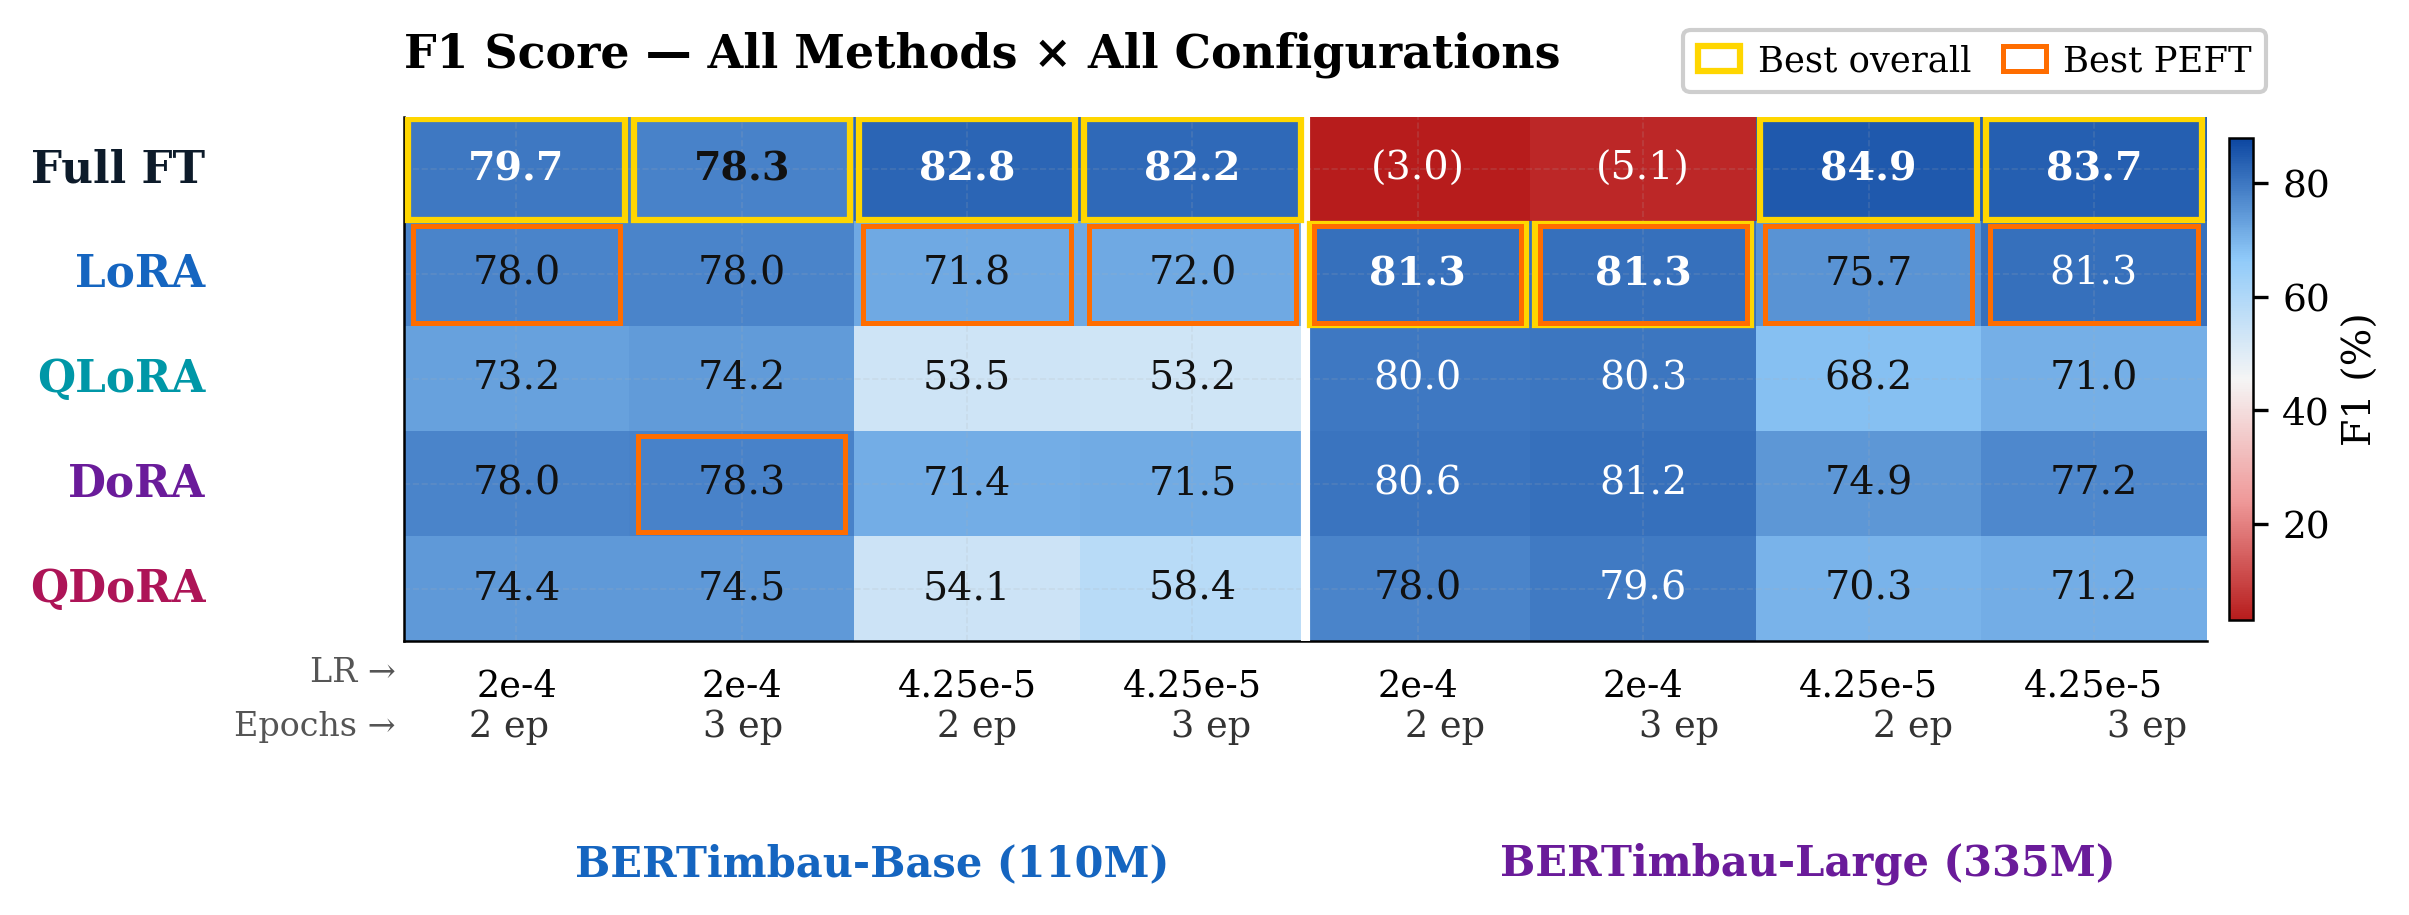

Fig 2 salva em figures


In [110]:
matrix = np.array([f1_all[m] for m in METHODS])

cmap_hm = LinearSegmentedColormap.from_list(
    'acm', ['#B71C1C', '#EF9A9A', '#F5F5F5', '#90CAF9', '#0D47A1'], N=256)

fig, ax = plt.subplots(figsize=(8, 3.8))

fig.subplots_adjust(left=0.10, right=0.88, top=0.84, bottom=0.38)

im = ax.imshow(matrix, cmap=cmap_hm, vmin=3, vmax=88,
               aspect='auto', interpolation='none')

# ── valores dentro de las celdas ─────────────────

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):

        val = matrix[i, j]

        tc  = 'white' if (val > 79 or val < 20) else '#111111'
        fw  = 'bold'  if (val == matrix[:, j].max() and val > 10) else 'normal'
        lbl = f'({val:.1f})' if val < 8 else f'{val:.1f}'

        ax.text(j, i, lbl,
                ha='center', va='center',
                fontsize=9.5,
                color=tc,
                fontweight=fw)

# ── learning rates ──────────────────────────────

col_lr = ['2e-4','2e-4','4.25e-5','4.25e-5'] * 2

ax.set_xticks(range(8))
ax.set_xticklabels(col_lr, fontsize=8.8, ha='center')

ax.tick_params(axis='x', pad=3, bottom=False)

fig.canvas.draw()

# ── posiciones horizontales de columnas ─────────

col_x = []

for j in range(8):

    xd = ax.transData.transform((j, 0))[0]
    col_x.append(xd / (fig.get_size_inches()[0] * fig.dpi))

# ── epochs ──────────────────────────────────────

col_ep = ['2 ep','3 ep','2 ep','3 ep'] * 2

y_ep  = 0.305
y_grp = 0.185

ep_offset = -0.005

for xf, ep in zip(col_x, col_ep):

    fig.text(xf + ep_offset, y_ep, ep,
             ha='center', va='center',
             fontsize=8.8,
             color='#333333')

# ── etiquetas de filas inferiores ───────────────

x_arrow = col_x[0] - 0.052

ax_y0   = ax.get_position().y0
tick_y  = ax_y0 - 0.028

fig.text(x_arrow, tick_y, 'LR →',
         ha='right', va='center',
         fontsize=8.0,
         color='#555555')

fig.text(x_arrow, y_ep, 'Epochs →',
         ha='right', va='center',
         fontsize=8.0,
         color='#555555')

# ── nombres de arquitectura ─────────────────────

x_base  = np.mean(col_x[:4])
x_large = np.mean(col_x[4:])

fig.text(x_base, y_grp, 'BERTimbau-Base (110M)',
         ha='center', va='center',
         fontsize=10.0,
         color='#1565C0',
         fontweight='bold')

fig.text(x_large, y_grp, 'BERTimbau-Large (335M)',
         ha='center', va='center',
         fontsize=10.0,
         color='#6A1B9A',
         fontweight='bold')

# ── eje Y ───────────────────────────────────────

ax.set_yticks(range(len(METHODS)))
ax.set_yticklabels([])

ax.tick_params(left=False)

for i, m in enumerate(METHODS):

    ax.text(-0.11, i, m,
            ha='right', va='center',
            fontsize=10.5,
            fontweight='bold',
            color=MC[m],
            transform=ax.get_yaxis_transform())

# ── separador entre Base y Large ────────────────

ax.axvline(3.5, color='white', linewidth=2.2, zorder=6)

# ── best overall ────────────────────────────────

for j in range(8):

    bi = int(np.argmax(matrix[:, j]))

    if matrix[bi, j] > 10:

        ax.add_patch(mpatches.FancyBboxPatch(
            (j-0.48, bi-0.48),
            0.96, 0.96,
            boxstyle='square,pad=0',
            lw=1.5,
            edgecolor='#FFD600',
            facecolor='none',
            zorder=7))

# ── best PEFT ───────────────────────────────────

peft_matrix = matrix[1:, :]

for j in range(8):

    bi_peft = int(np.argmax(peft_matrix[:, j])) + 1

    if peft_matrix[bi_peft - 1, j] > 10:

        ax.add_patch(mpatches.FancyBboxPatch(
            (j-0.46, bi_peft-0.46),
            0.92, 0.92,
            boxstyle='square,pad=0',
            lw=1.2,
            edgecolor='#FF6D00',
            facecolor='none',
            zorder=8))

# ── colorbar ────────────────────────────────────

cbar = fig.colorbar(im,
                    ax=ax,
                    fraction=0.025,
                    pad=0.012,
                    shrink=0.92)

cbar.ax.tick_params(labelsize=9.0)

cbar.set_label('F1 (%)',
               fontsize=9.5,
               labelpad=3)

# ── título ──────────────────────────────────────

ax.set_title('F1 Score — All Methods × All Configurations',
             fontweight='bold',
             pad=12,
             loc='left',
             fontsize=11.0)

# ── leyenda ─────────────────────────────────────

legend_handles = [

    mpatches.Patch(edgecolor='#FFD600',
                   facecolor='none',
                   lw=1.5,
                   label='Best overall'),

    mpatches.Patch(edgecolor='#FF6D00',
                   facecolor='none',
                   lw=1.2,
                   label='Best PEFT'),
]

ax.legend(handles=legend_handles,
          loc='upper left',
          bbox_to_anchor=(0.70, 1.200),
          frameon=True,
          edgecolor='#cccccc',
          framealpha=0.95,
          fontsize=8.5,
          handlelength=1.2,
          handletextpad=0.5,
          borderpad=0.4,
          ncol=2,
          columnspacing=0.9)

# ── guardar figura ──────────────────────────────

plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_heatmap.pdf'),
            dpi=300,
            bbox_inches='tight')

plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_heatmap.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

print('Fig 2 salva em', OUTPUT_DIR)

## 5. Checklist pré-submissão

### Arquivos gerados
- [ ] `figures/fig1_ram.pdf` — Fig 1, 1 coluna ACM (3.5 in)
- [ ] `figures/fig2_heatmap.pdf` — Fig 2, 2 colunas ACM (7.16 in)

### LaTeX — substituir referências antigas
```latex
% Fig 1 — substituir \ref{fig:base_detailed}
\begin{figure}[h]
\centering
\includegraphics[width=0.48\textwidth]{fig/fig1_ram.pdf}
\caption{Peak GPU memory consumption by method and architecture.
Quantized methods reduce memory by up to 86.9\% (Base) and 81.9\% (Large)
vs. full fine-tuning. The dashed red line marks the 20\,GB GPU limit.}
\label{fig:ram}
\end{figure}

% Fig 2 — substituir \ref{fig:lr_comparison}
\begin{figure*}[ht!]
\centering
\includegraphics[width=\textwidth]{fig/fig2_heatmap.pdf}
\caption{F1 score for all methods and configurations.
Gold border: best overall per column. Orange border: best PEFT method.
Values in parentheses indicate training collapse (Full FT, Large, lr=2e-4).
Panel (a) BERTimbau-Base (110M); panel (b) BERTimbau-Large (335M).}
\label{fig:heatmap}
\end{figure*}
```

### Verificação de dados
- [x] 12 valores de RAM verificados contra Tabela 5
- [x] 40 valores de F1 verificados contra Tabelas 1–4
- [x] Cores consistentes entre Fig 1 e Fig 2 (paleta `MC`)